In [24]:
# The aim of the assignment is to simulate the BB84 key distribution protocol.
# This notebook is for a simulation of the protocol without an attacker.
%pip install qiskit==1.2.4
%pip install qiskit-aer==0.15.1
%pip install pylatexenc==2.10

from qiskit import QuantumCircuit
from qiskit.converters import circuit_to_gate
from qiskit.visualization import array_to_latex
from qiskit.quantum_info import Operator
from qiskit.quantum_info import Statevector
from qiskit import transpile
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.visualization import plot_histogram
from qiskit.circuit import ControlledGate
import math

backend = BasicSimulator()

In [25]:
def make_random_bit(backend):
  """
  Generate a single random bit using quantum measurement:
  prepare (|0> + |1>)/sqrt(2) with H, then measure.
  """
  qc = QuantumCircuit(1, 1)
  qc.h(0)
  qc.measure(0, 0)

  tqc = transpile(qc, backend)
  result = backend.run(tqc, shots=1).result()
  counts = result.get_counts()
  bit_str = max(counts, key=counts.get)
  return int(bit_str)

def quantum_random_bits(n, backend):
  """
  Generate n random bits using repeated quantum measurements.
  """
  return [make_random_bit(backend) for _ in range(n)]

sample_bits = quantum_random_bits(10, backend)
print("Sample quantum random bits:",sample_bits)

Sample quantum random bits: [0, 1, 1, 0, 0, 1, 1, 1, 0, 0]


In [26]:
def send_and_measure(alice_bit, alice_basis, bob_basis, backend):
  """
  Simulate BB84 for a single qubit, without an attacker.

  alice_bit   : 0 or 1 (Alice's data bit)
  alice_basis : 0 (Z basis) or 1 (X basis)
  bob_basis   : 0 (Z basis) or 1 (X basis)

  Returns:
      bob_result_bit : 0 or 1 (Bob's measurement result)
  """
  qc = QuantumCircuit(1, 1)

  # Alice's side: encode the bit into a qubit
  if alice_bit == 1:
      qc.x(0)
  if alice_basis == 1:
      qc.h(0)

  # Bob's side: choose measurement basis and measure
  if bob_basis == 1:
      qc.h(0)

  qc.measure(0, 0)

  tqc = transpile(qc, backend)
  result = backend.run(tqc, shots=1).result()
  counts = result.get_counts()
  bit_str = max(counts, key=counts.get)
  bob_result_bit = int(bit_str)

  return bob_result_bit

print("Single-qubit demo:\n(alice_bit, alice_basis, bob_basis) -> bob_result")
for (a_bit, a_basis, b_basis) in [(0,0,0), (1,0,0), (0,1,1), (1,1,1), (1,0,1), (0,1,0)]:
    out = send_and_measure(a_bit, a_basis, b_basis, backend)
    print(f"  ({a_bit}, {a_basis}, {b_basis}) -> {out}")

Single-qubit demo:
(alice_bit, alice_basis, bob_basis) -> bob_result
  (0, 0, 0) -> 0
  (1, 0, 0) -> 1
  (0, 1, 1) -> 0
  (1, 1, 1) -> 1
  (1, 0, 1) -> 0
  (0, 1, 0) -> 1


In [27]:
def run_bb84_plain(num_qubits=200, backend=backend, verbose=True):
  # Alice: generate random data bits and bases
  alice_bits = quantum_random_bits(num_qubits, backend)
  alice_bases = quantum_random_bits(num_qubits, backend)

  # Bob: generate random measurement bases
  bob_bases = quantum_random_bits(num_qubits, backend)

  # Quantum transmission and measurement
  bob_results = []
  for i in range(num_qubits):
      bit = alice_bits[i]
      a_basis = alice_bases[i]
      b_basis = bob_bases[i]

      bob_bit = send_and_measure(bit, a_basis, b_basis, backend)
      bob_results.append(bob_bit)

  # Classical communication: basis comparison (sifting)
  # Alice and Bob publicly compare their bases and keep only positions
  # where the bases match (these positions form the sifted key).
  sift_indices = [i for i in range(num_qubits) if alice_bases[i] == bob_bases[i]]

  alice_key = [alice_bits[i] for i in sift_indices]
  bob_key = [bob_results[i] for i in sift_indices]

  # Error rate computation
  if len(alice_key) == 0:
      error_rate = 0.0
      num_errors = 0
  else:
      num_errors = sum(1 for a, b in zip(alice_key, bob_key) if a != b)
      error_rate = num_errors / len(alice_key)

  if verbose:
      print("<<<< BB84 without attacker >>>>")
      print(f"Total qubits sent: {num_qubits}")
      print(f"Sifted key length: {len(alice_key)}")
      print(f"Number of mismatches in sifted key: {num_errors}")
      print(f"Error rate in sifted key: {error_rate:.2%}")

      # Show the first few bits of the keys
      print("Alice's sifted key (first 32 bits):", alice_key[:32])
      print("Bob's   sifted key (first 32 bits):", bob_key[:32])

  return {
      "alice_bits": alice_bits,
      "alice_bases": alice_bases,
      "bob_bases": bob_bases,
      "bob_results": bob_results,
      "sift_indices": sift_indices,
      "alice_key": alice_key,
      "bob_key": bob_key,
      "error_rate": error_rate,
  }

In [28]:
results_plain = run_bb84_plain(num_qubits=200, backend=backend, verbose=True)

<<<< BB84 without attacker >>>>
Total qubits sent: 200
Sifted key length: 99
Number of mismatches in sifted key: 0
Error rate in sifted key: 0.00%
Alice's sifted key (first 32 bits): [0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0]
Bob's   sifted key (first 32 bits): [0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0]


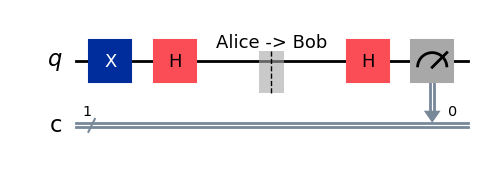

In [31]:
circuit = QuantumCircuit(1, 1)

# Alice encodes (bit=1, basis=X)
circuit.x(0)   # prepare |1>
circuit.h(0)   # move to X basis: |1> -> |->

# Channel
circuit.barrier(label="Alice -> Bob")

# Bob measures in X basis
circuit.h(0)       # rotate to X basis measurement
circuit.measure(0, 0)

circuit.draw("mpl")